In [5]:
# Import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Dataset path
# The notebook is inside /notebooks, so ".." returns to the project root
data_path = Path("../data/processed/electrical_current_with_shop.csv")

# Load the dataset
df = pd.read_csv(data_path)

# Convert Time into datetime format
df["Time"] = pd.to_datetime(df["Time"])

# Find all columns that correspond to robot axes
axis_columns = [
    col for col in df.columns
    if col.startswith("Axis #")
]

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)
print("Robots:", df["Robot_ID"].unique())
print("Number of robots:", df["Robot_ID"].nunique())
print("Axes:", axis_columns)

Dataset loaded successfully!
Dataset shape: (39692, 22)
Robots: <StringArray>
['ROBOT-001', 'ROBOT-002', 'ROBOT-003']
Length: 3, dtype: str
Number of robots: 3
Axes: ['Axis #1', 'Axis #2', 'Axis #3', 'Axis #4', 'Axis #5', 'Axis #6', 'Axis #7', 'Axis #8', 'Axis #9', 'Axis #10', 'Axis #11', 'Axis #12', 'Axis #13', 'Axis #14']


In [6]:
# Dictionary where we will store the statistics
# for each robot
robot_statistics = {}

# Analyze every robot separately
for robot in df["Robot_ID"].unique():

    # Select only the records belonging to this robot
    robot_data = df[df["Robot_ID"] == robot]

    # Some robots may not use every axis.
    # Keep only axes that contain actual values.
    active_axes = [
        axis for axis in axis_columns
        if robot_data[axis].notna().any()
    ]

    # Calculate statistical measurements for each active axis
    statistics = pd.DataFrame({
        "Mean": robot_data[active_axes].mean(),
        "Std": robot_data[active_axes].std(),
        "Variance": robot_data[active_axes].var(),
        "Min": robot_data[active_axes].min(),
        "Max": robot_data[active_axes].max()
    })

    # Range measures the distance between
    # the maximum and minimum values
    statistics["Range"] = (
        statistics["Max"] - statistics["Min"]
    )

    # Save results for this robot
    robot_statistics[robot] = statistics

print("Dispersion statistics calculated successfully!")

Dispersion statistics calculated successfully!


In [7]:
# Display statistics for every robot
for robot, stats in robot_statistics.items():

    print(f"\n===== {robot} =====")

    display(stats.round(3))


===== ROBOT-001 =====


,Mean,Std,Variance,Min,Max,Range
Axis #1,0.726,2.162,4.675,0.0,23.609,23.609
Axis #2,3.613,6.880,47.334,0.0,51.713,51.713
Axis #3,2.710,5.112,26.132,0.0,41.856,41.856
Axis #4,0.620,1.575,2.480,0.0,15.666,15.666
Axis #5,0.955,2.100,4.411,0.0,20.751,20.751
Axis #6,0.599,1.815,3.296,0.0,20.931,20.931
Axis #7,0.870,2.167,4.695,0.0,8.108,8.108
Axis #8,0.102,0.423,0.179,0.0,5.906,5.906



===== ROBOT-002 =====


,Mean,Std,Variance,Min,Max,Range
Axis #1,0.265,0.03,0.001,0.22,0.31,0.09
Axis #2,0.285,0.03,0.001,0.24,0.33,0.09
Axis #3,0.305,0.03,0.001,0.26,0.35,0.09
Axis #4,0.325,0.03,0.001,0.28,0.37,0.09
Axis #5,0.345,0.03,0.001,0.30,0.39,0.09
Axis #6,0.365,0.03,0.001,0.32,0.41,0.09
Axis #7,0.385,0.03,0.001,0.34,0.43,0.09
Axis #8,0.405,0.03,0.001,0.36,0.45,0.09
Axis #9,0.425,0.03,0.001,0.38,0.47,0.09
Axis #10,0.445,0.03,0.001,0.40,0.49,0.09



===== ROBOT-003 =====


,Mean,Std,Variance,Min,Max,Range
Axis #1,0.365,0.03,0.001,0.32,0.41,0.09
Axis #2,0.385,0.03,0.001,0.34,0.43,0.09
Axis #3,0.405,0.03,0.001,0.36,0.45,0.09
Axis #4,0.425,0.03,0.001,0.38,0.47,0.09
Axis #5,0.445,0.03,0.001,0.40,0.49,0.09
Axis #6,0.465,0.03,0.001,0.42,0.51,0.09
Axis #7,0.485,0.03,0.001,0.44,0.53,0.09
Axis #8,0.505,0.03,0.001,0.46,0.55,0.09
Axis #9,0.525,0.03,0.001,0.48,0.57,0.09
Axis #10,0.545,0.03,0.001,0.50,0.59,0.09


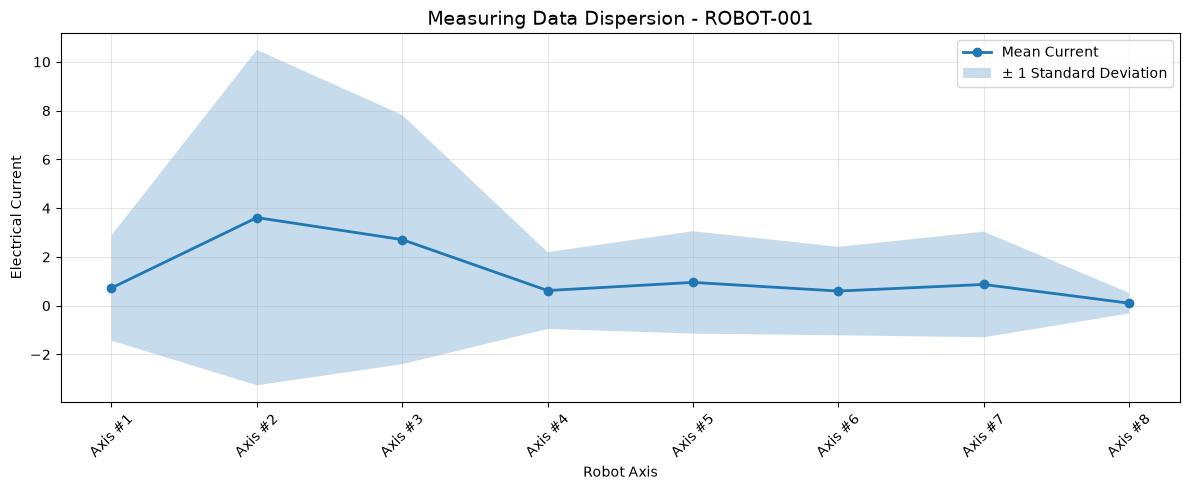

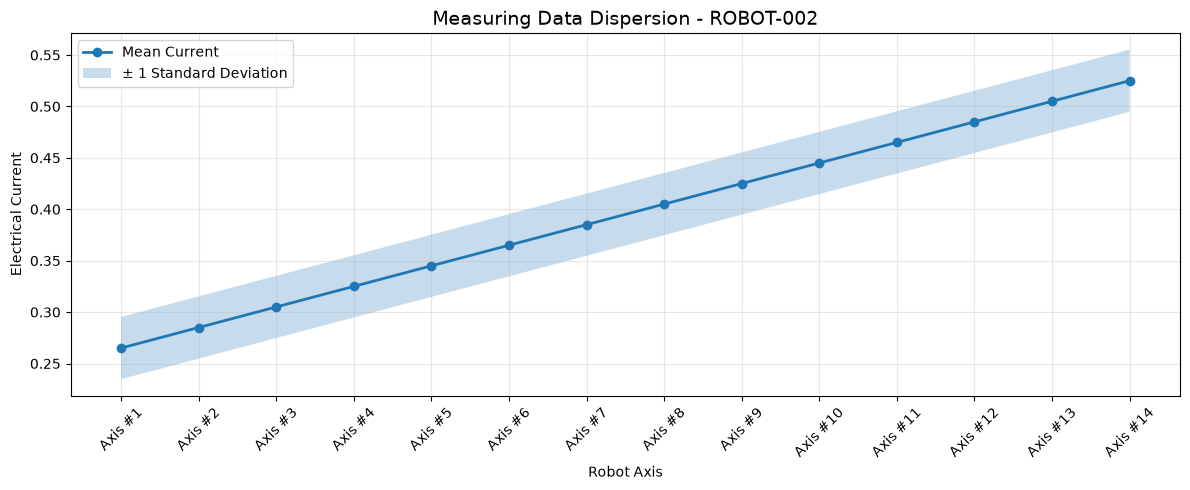

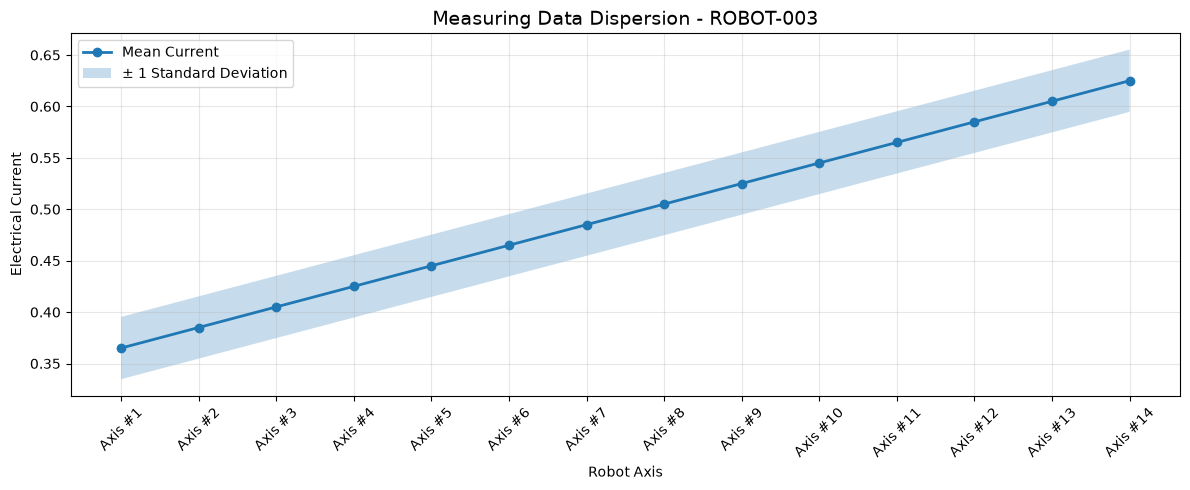

In [8]:
# Create one dispersion graph for each robot
for robot, stats in robot_statistics.items():

    # Create the graph
    plt.figure(figsize=(12, 5))

    # X-axis positions
    x = np.arange(len(stats))

    # -----------------------------
    # Mean electrical current
    # -----------------------------
    plt.plot(
        x,
        stats["Mean"],
        marker="o",
        linewidth=2,
        label="Mean Current"
    )

    # -----------------------------
    # Standard deviation area
    # Mean ± Standard Deviation
    # -----------------------------
    plt.fill_between(
        x,
        stats["Mean"] - stats["Std"],
        stats["Mean"] + stats["Std"],
        alpha=0.25,
        label="± 1 Standard Deviation"
    )

    # -----------------------------
    # Graph configuration
    # -----------------------------
    plt.title(
        f"Measuring Data Dispersion - {robot}",
        fontsize=14
    )

    plt.xlabel("Robot Axis")
    plt.ylabel("Electrical Current")

    # Show axis names
    plt.xticks(
        x,
        stats.index,
        rotation=45
    )

    plt.grid(
        True,
        alpha=0.3
    )

    plt.legend()

    plt.tight_layout()

    # Display graph
    plt.show()